<div style="background:linear-gradient(135deg,#111827 0%,#312e81 52%,#7c3aed 100%);border-radius:28px;padding:58px 42px;color:white;text-align:center;margin:0 0 28px;box-shadow:0 18px 45px rgba(49,46,129,.25);font-family: Times New Roman">
<div style="font-size:15px;letter-spacing:3px;text-transform:uppercase;opacity:.82;font-weight:700;">End-to-End Machine Learning Project</div>
<h1 style="font-size:48px;margin:18px 0 10px;font-weight:800;">Employee Attrition Prediction</h1>
<p style="font-size:20px;opacity:.92;margin:0 auto;max-width:780px;line-height:1.6;">A business-focused classification system for identifying employees who may be at risk of leaving an organization.</p>
<div style="margin:30px auto 0;display:inline-block;background:rgba(255,255,255,.12);border:1px solid rgba(255,255,255,.2);border-radius:16px;padding:15px 24px;font-size:15px;">EDA • Preprocessing • Baseline Models • XGBoost • Tuning • Evaluation • Deployment</div>
</div>
<div style="display:flex;gap:14px;flex-wrap:wrap;margin:0 0 25px;font-family: Times New Roma">
<div style="flex:1;min-width:180px;background:#f8fafc;border:1px solid #e5e7eb;border-radius:16px;padding:18px;text-align:center;"><div style="font-size:25px;">🎯</div><b>Objective</b><br><span style="color:#667085;font-size:13px;">Predict employee attrition</span></div>
<div style="flex:1;min-width:180px;background:#f8fafc;border:1px solid #e5e7eb;border-radius:16px;padding:18px;text-align:center;"><div style="font-size:25px;">📊</div><b>Approach</b><br><span style="color:#667085;font-size:13px;">Comparative classification</span></div>
<div style="flex:1;min-width:180px;background:#f8fafc;border:1px solid #e5e7eb;border-radius:16px;padding:18px;text-align:center;"><div style="font-size:25px;">🚀</div><b>Outcome</b><br><span style="color:#667085;font-size:13px;">Deployment-ready model</span></div>
</div>
<div style="text-align:center;color:#667085;font-size:13px;margin-bottom:25px;">Prepared as a professional portfolio / academic ML project notebook</div>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Project Guide</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Project Checklist Coverage</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">A structured roadmap showing how the notebook covers the complete machine-learning workflow.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roma">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roma"> 

## 📋 Project Checklist Coverage

This notebook is structured to follow the supplied **Machine Learning Project Guidelines**:

1. Problem Statement
2. Data Collection
3. Data Understanding
4. Exploratory Data Analysis (EDA)
5. Data Cleaning
6. Data Preprocessing
7. Model Building
8. Model Evaluation
9. Hyperparameter Tuning
10. Final Model Selection

The guideline explicitly emphasizes understanding the complete end-to-end workflow rather than only maximizing model accuracy.
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roma">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 01</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Environment & Library Setup</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Import the analytical, visualization, preprocessing, and modeling libraries required throughout the notebook.</p></div>


In [29]:
# IMPORT LIBRARIES

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

import joblib
print("Libraries imported successfully.")

TARGET = "Attrition"
RANDOM_STATE = 42


Libraries imported successfully.


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Stage 01</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Problem Statement</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Define the business objective, prediction target, and success criteria.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roma">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roman">

# 1️⃣ Problem Statement

**Problem:** Predict employee attrition using demographic, professional, compensation, work-environment, engagement, satisfaction, and employee-support attributes.

**Target variable:** `Attrition`

- `Yes` → Employee attrition
- `No` → Employee remains

**ML task:** Binary Classification

**Primary business use:** Early identification of employee profiles associated with higher attrition risk, so HR can investigate underlying causes and design appropriate retention interventions.
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Stage 02</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Data Collection</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Identify the source dataset and establish the data foundation for the project.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roman">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roman">

# 2️⃣ Data Collection

The project uses the user-provided file:

`Original Dataset of Employee Attrition.xlsx`

The supplied project guideline permits datasets from sources such as Kaggle, Hugging Face, UCI, government portals, and other reliable public sources. 

**Dataset provenance note:** The workbook itself does not contain a source URL or provenance field. Therefore, the dataset is documented here as **user-provided**, and its public-source/real-vs-dummy status should be verified from the original download/source before final submission.
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 02</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Load the Dataset</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Read the employee dataset into a pandas DataFrame and establish the working dataset used by the project.</p></div>


In [2]:
# LOAD DATA

df = pd.read_excel("employee_attrition.xlsx")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (1191, 35)


,ID,Attrition,Gender,Age,Maritalstatus,Academic_degree,Years_Experience,Years_experience_lastorganization,Sector,Department,...,Job_Engagement,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities
0,11,Yes,Female,31 to 40,Married,Master's,Less than 5 years,Less than 5 years,Medical sector,Accounting,...,Medium,Medium,Medium,Yes,No,No,Yes,Medium,Not satisfied,Yes
1,12,No,Female,21 to 30,Single,Master's,Less than 5 years,Less than 5 years,Medical sector,Accounting,...,Medium,Medium,Medium,No,No,Yes,No,Medium,Satisfied,No
2,13,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Close,Medium,Yes,Sometimes,No,No,Medium,Satisfied,Yes
3,14,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Medium,Medium,Yes,Yes,No,No,Low,Not satisfied,No
4,15,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Medium,Medium,Sometimes,Sometimes,No,No,Medium,Not satisfied,No


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Stage 03</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Data Understanding</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Inspect structure, variables, data types, target distribution, and data quality.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roman">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roman">

# 3️⃣ Data Understanding

We inspect:

- Dataset shape
- Column names
- Data types
- Target variable
- Unique values
- Missing values
- Duplicate records
- Class distribution

The project guideline specifically asks for shape, columns, data types, target variable, etc.
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 03</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Data Understanding</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Inspect dimensions, columns, data types, and target-related information before making modeling decisions.</p></div>


In [3]:
# DATA UNDERSTANDING

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nTarget distribution:")
display(df["Attrition"].value_counts(dropna=False))

print("\nTarget percentage:")
display((df["Attrition"].value_counts(normalize=True) * 100).round(2))

print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))


Shape: (1191, 35)

Columns:
['ID', 'Attrition', 'Gender ', 'Age', ' Maritalstatus', '\xa0Academic_degree ', 'Years_Experience', 'Years_experience_lastorganization', 'Sector', 'Department', 'JobTitle', 'MonthlySalary', 'Allowances', 'MedicalInsurance', 'Bonus', 'OverTime', 'Payment_Overtime', 'Rewards&Wages_Satisfaction', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Useful_Training_Programs', 'Business_Travel', 'Job_Support', 'Recognition', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Health_Issues', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities']

Data types:


,dtype
ID,int64
Attrition,str
Gender,str
Age,str
Maritalstatus,str
Academic_degree,str
Years_Experience,str
Years_experience_lastorganization,str
Sector,str
Department,str



Target distribution:


Attrition
No     676
Yes    515
Name: count, dtype: int64


Target percentage:


Attrition
No     56.76
Yes    43.24
Name: proportion, dtype: float64


Duplicate rows: 0

Missing values:


,missing
ID,0
Attrition,0
Gender,0
Age,0
Maritalstatus,0
Academic_degree,0
Years_Experience,0
Years_experience_lastorganization,0
Sector,0
Department,0


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 04</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Dataset Profile</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Generate a compact profile of the dataset to understand its structure and quality.</p></div>


In [4]:
# DATA PROFILE

profile = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing": df.isna().sum().values,
    "Unique_Values": df.nunique(dropna=True).values
})

display(profile)


,Column,Data_Type,Missing,Unique_Values
0,ID,int64,0,1191
1,Attrition,str,0,2
2,Gender,str,0,2
3,Age,str,0,4
4,Maritalstatus,str,0,4
5,Academic_degree,str,0,5
6,Years_Experience,str,0,10
7,Years_experience_lastorganization,str,0,7
8,Sector,str,0,16
9,Department,str,0,26


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Stage 04</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Exploratory Data Analysis (EDA)</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Use visual and statistical analysis to uncover patterns, imbalance, relationships, and potential signals.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roman">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roman">

# 4️⃣ Exploratory Data Analysis (EDA)

The guideline requires summary statistics, missing values, duplicates, univariate analysis, bivariate analysis, correlation analysis, and visualizations. 

Each visualization should answer a meaningful question rather than being included only for decoration.
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 05</div><h2 style="margin:0;color:#1f2937;font-size:25px;">EDA — Exploration Setup</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Prepare the dataset for exploratory analysis and create analysis-friendly representations where required.</p></div>


In [5]:
# 4. EDA — CLEAN TEXT FOR EXPLORATION

eda_df = df.copy()

# Normalize column names and text values for consistent analysis.
eda_df.columns = [
    str(c).replace("\xa0", " ").strip()
    for c in eda_df.columns
]

for col in eda_df.select_dtypes(include="object").columns:
    eda_df[col] = (
        eda_df[col].astype(str)
        .str.replace("\xa0", " ", regex=False)
        .str.strip()
    )

print("Cleaned column names:")
print(eda_df.columns.tolist())


Cleaned column names:
['ID', 'Attrition', 'Gender', 'Age', 'Maritalstatus', 'Academic_degree', 'Years_Experience', 'Years_experience_lastorganization', 'Sector', 'Department', 'JobTitle', 'MonthlySalary', 'Allowances', 'MedicalInsurance', 'Bonus', 'OverTime', 'Payment_Overtime', 'Rewards&Wages_Satisfaction', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Useful_Training_Programs', 'Business_Travel', 'Job_Support', 'Recognition', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Health_Issues', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities']


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 06</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Summary Statistics</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Review numerical and categorical summaries to understand central tendency, spread, and category frequency.</p></div>


In [6]:
# SUMMARY STATISTICS

display(eda_df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,1191.0,NaN,NaN,NaN,612.910999,346.732295,11.0,314.5,613.0,912.5,1213.0
Attrition,1191,2,No,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1191,2,Female,678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1191,4,21 to 30,592,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Maritalstatus,1191,3,Married,686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic_degree,1191,4,Bachelor's,764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years_Experience,1191,7,From 5 to 10 years,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years_experience_lastorganization,1191,7,Less than 5 years,716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sector,1191,16,Medical sector,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,1191,23,Administration,194,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 07</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Missing-Value Analysis</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Identify missing observations and quantify where data-quality treatment may be required.</p></div>


In [7]:
# MISSING VALUES

missing = eda_df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("Missing_Values"))

print("Total missing cells:", int(eda_df.isna().sum().sum()))


,Missing_Values


Total missing cells: 0


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 08</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Duplicate Analysis</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Check for duplicate records that could bias analysis or model training.</p></div>


In [8]:
# DUPLICATES

print("Duplicate rows:", eda_df.duplicated().sum())
print("Duplicate IDs:", eda_df["ID"].duplicated().sum())


Duplicate rows: 0
Duplicate IDs: 0


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 09</div><h2 style="margin:0;color:#1f2937;font-size:25px;">UNIVARIATE ANALYSIS - Target Distribution</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Measure the distribution of the attrition target and identify class imbalance.</p></div>


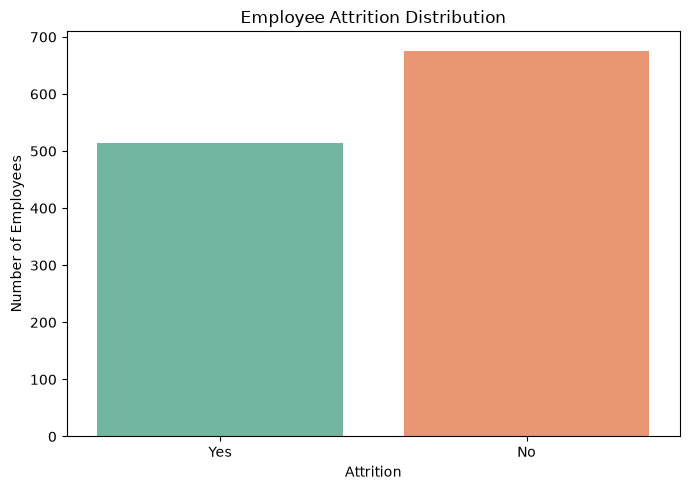

In [9]:
# UNIVARIATE ANALYSIS — TARGET

target_counts = eda_df["Attrition"].value_counts()

plt.figure(figsize=(7, 5))
sns.countplot(x="Attrition", data=eda_df, palette="Set2")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 10</div><h2 style="margin:0;color:#1f2937;font-size:25px;">UNIVARIATE ANALYSIS - Categorical Feature Analysis</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Explore selected categorical variables and their relationship with employee outcomes.</p></div>


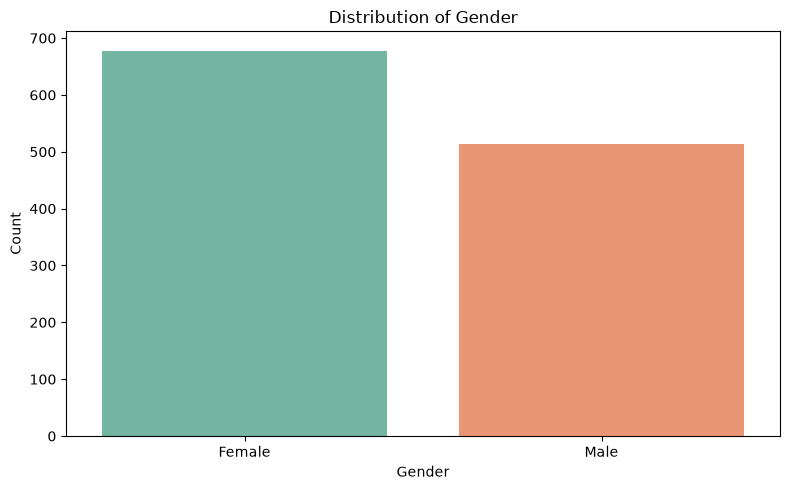

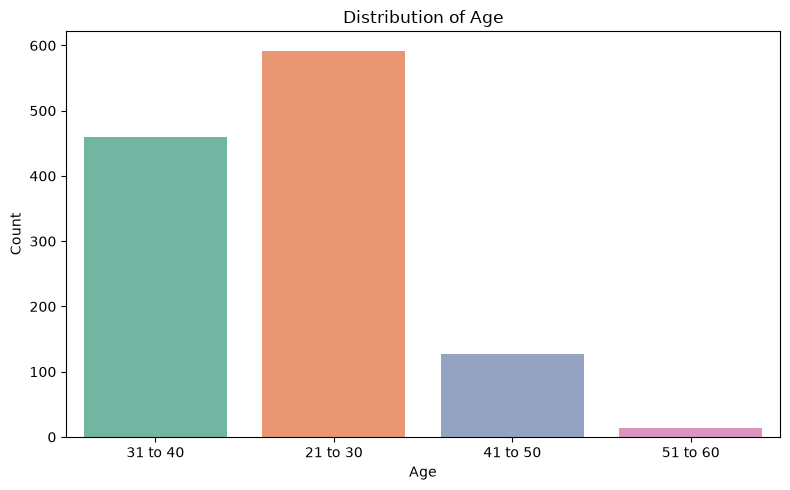

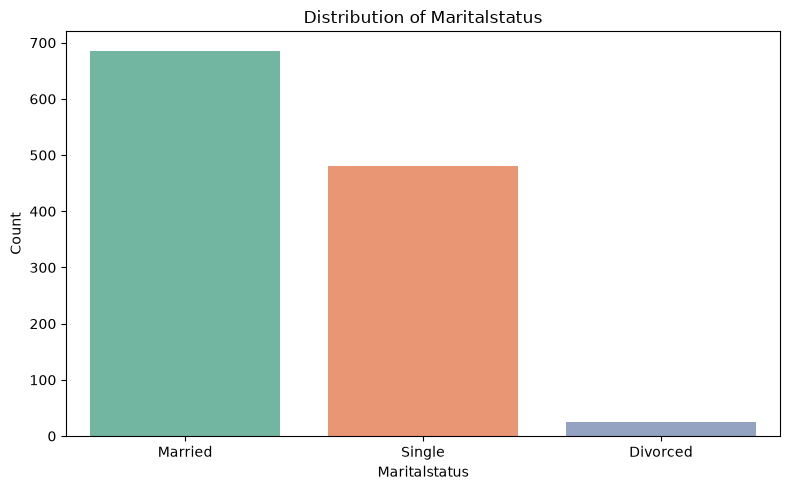

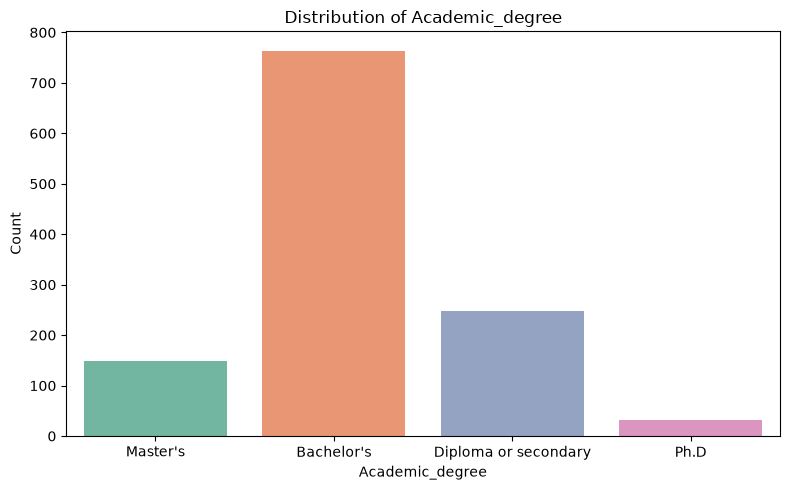

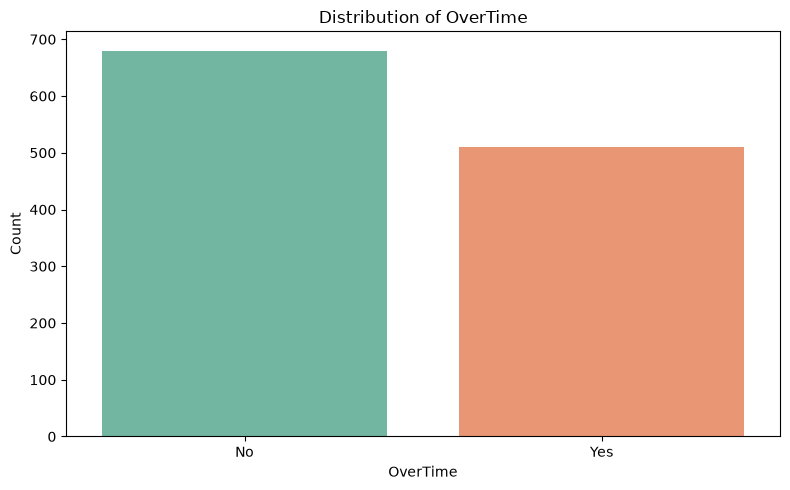

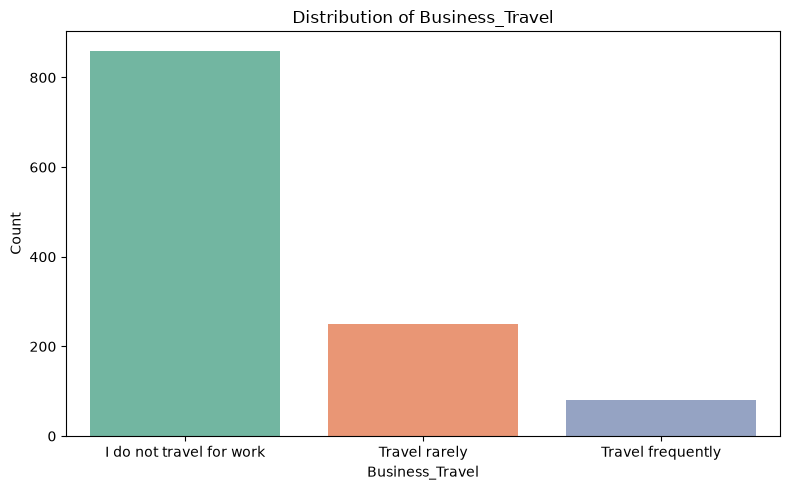

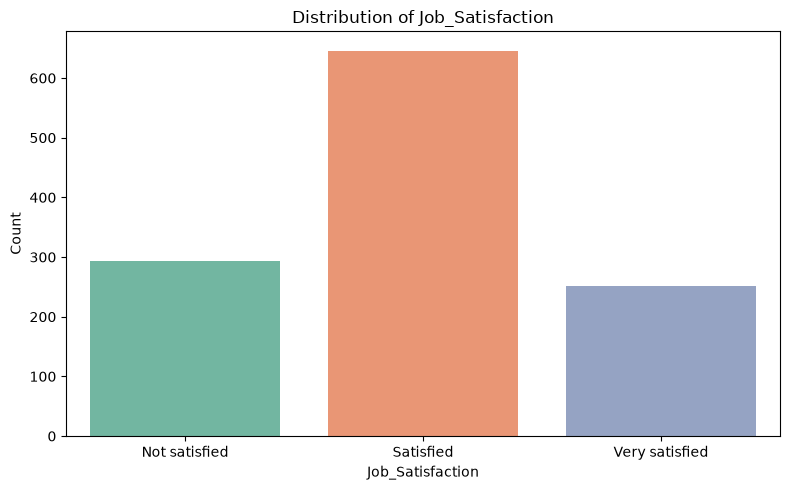

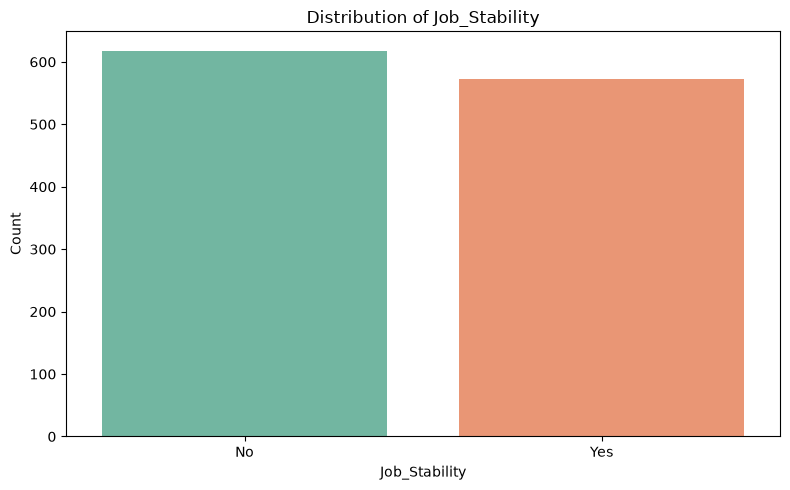

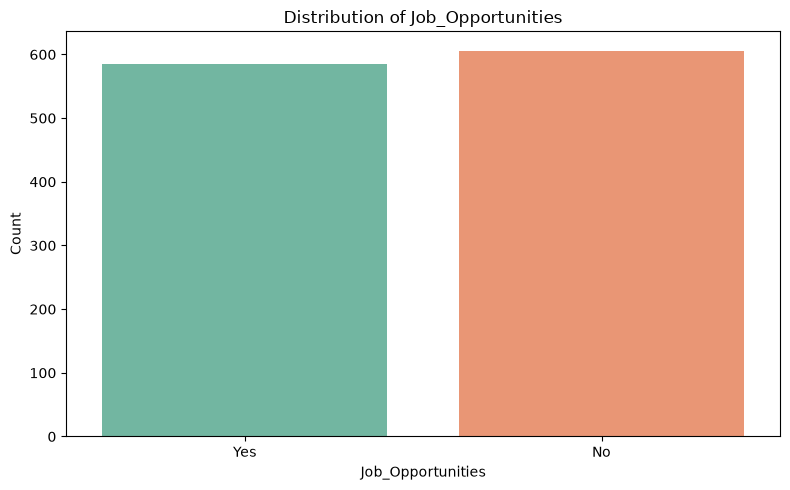

In [ ]:
# UNIVARIATE ANALYSIS — SELECTED CATEGORICAL FEATURES

selected_features = [
    "Gender", "Age", "Maritalstatus", "Academic_degree",
    "OverTime", "Business_Travel", "Job_Satisfaction",
    "Job_Stability", "Job_Opportunities"
]

for col in selected_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=eda_df, palette="Set2")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0)  

    plt.tight_layout()
    plt.show()


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 11</div><h2 style="margin:0;color:#1f2937;font-size:25px;">BIVARIATE ANALYSIS — Attrition Rate Analysis</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Compare attrition rates across important employee segments to uncover actionable patterns.</p></div>



Attrition percentage by OverTime:


Attrition,No,Yes
OverTime,,
Yes,56.16,43.84
No,57.21,42.79


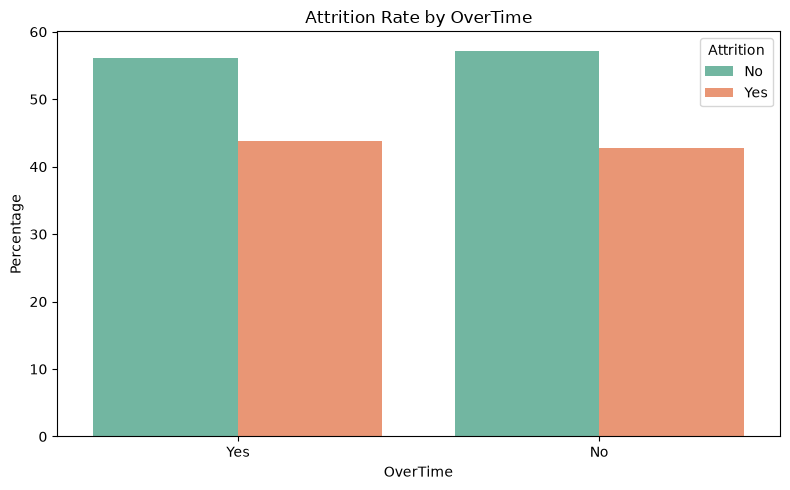


Attrition percentage by Job_Satisfaction:


Attrition,No,Yes
Job_Satisfaction,,
Not satisfied,41.64,58.36
Satisfied,56.81,43.19
Very satisfied,74.21,25.79


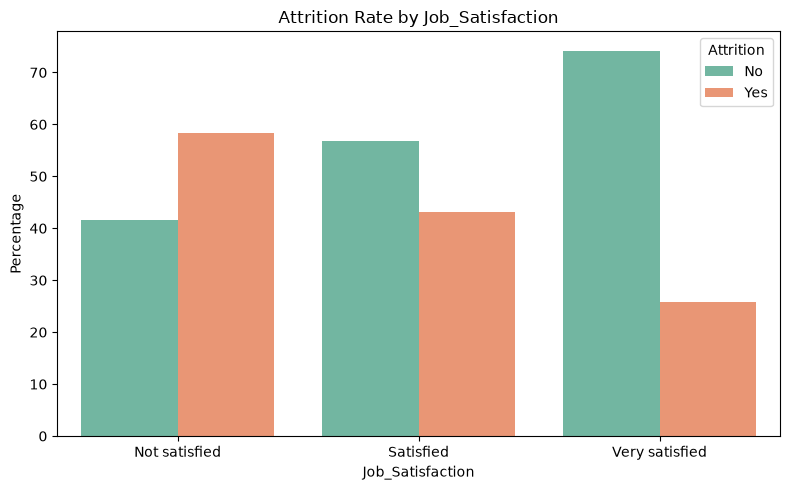


Attrition percentage by Job_Stability:


Attrition,No,Yes
Job_Stability,,
No,44.66,55.34
Yes,69.81,30.19


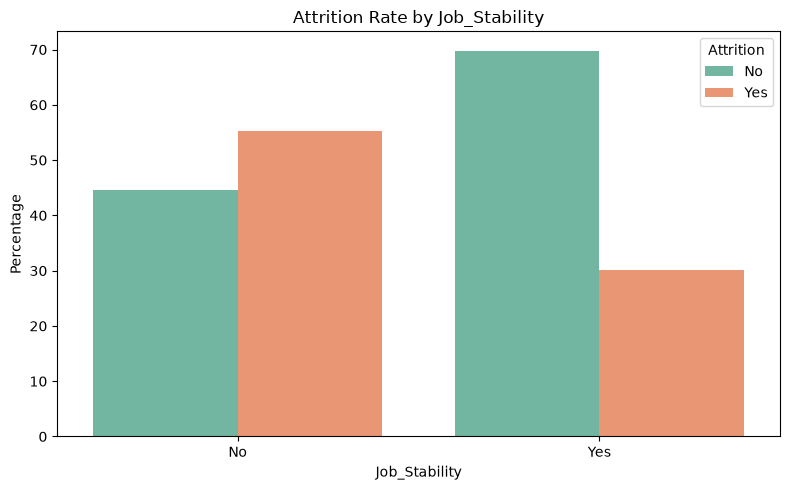


Attrition percentage by Job_Opportunities:


Attrition,No,Yes
Job_Opportunities,,
Yes,39.15,60.85
No,73.76,26.24


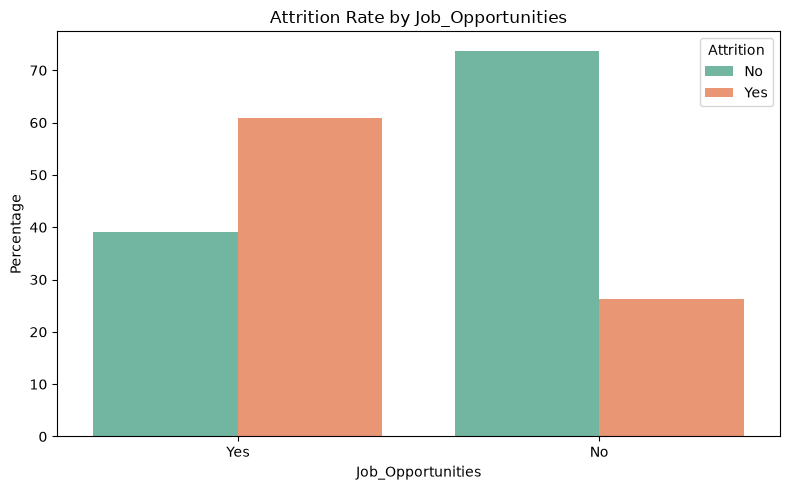


Attrition percentage by Business_Travel:


Attrition,No,Yes
Business_Travel,,
Travel frequently,50.00,50.00
I do not travel for work,56.86,43.14
Travel rarely,58.57,41.43


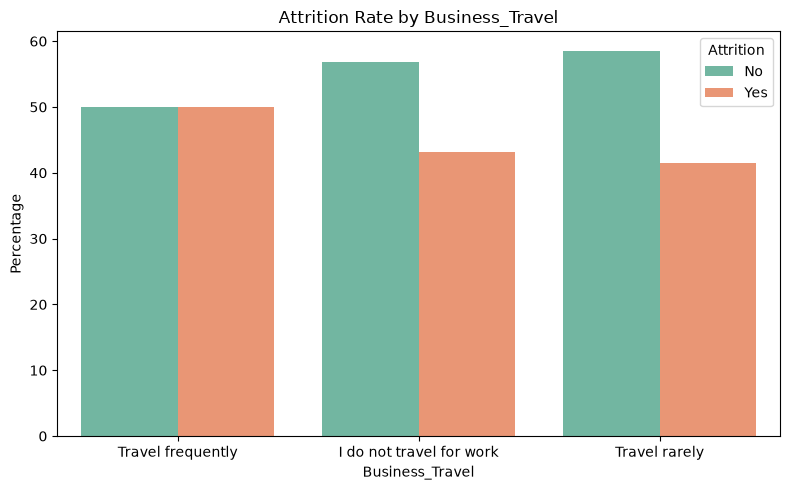


Attrition percentage by Work_Live_Balance:


Attrition,No,Yes
Work_Live_Balance,,
Difficult,40.09,59.91
Medium,58.92,41.08
Easy,65.45,34.55


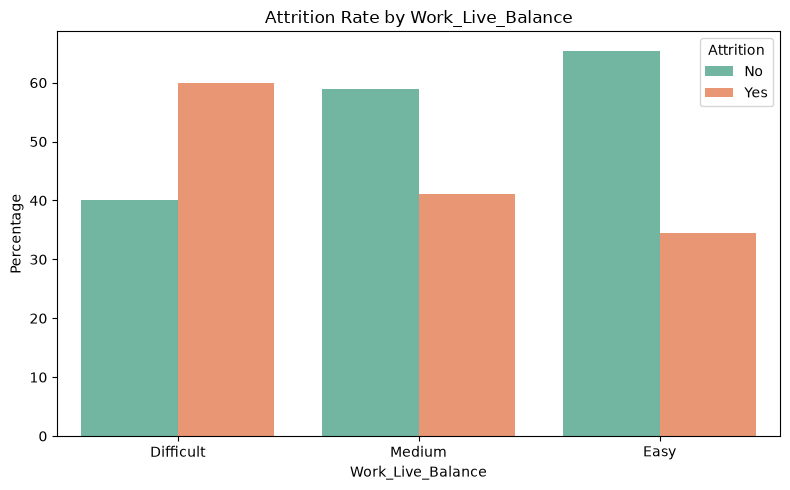

In [24]:
for col in ["OverTime", "Job_Satisfaction", "Job_Stability",
            "Job_Opportunities", "Business_Travel", "Work_Live_Balance"]:
    
    # Crosstab with percentages
    rate = pd.crosstab(
        eda_df[col],
        eda_df["Attrition"],
        normalize="index"
    ).mul(100)

    if "Yes" in rate.columns:
        rate = rate.sort_values("Yes", ascending=False)

    print(f"\nAttrition percentage by {col}:")
    display(rate.round(2))

    # Convert to long format for seaborn
    rate_long = rate.reset_index().melt(id_vars=col, var_name="Attrition", value_name="Percentage")

    plt.figure(figsize=(8, 5))
    sns.barplot(x=col, y="Percentage", hue="Attrition", data=rate_long, palette="Set2")

    plt.title(f"Attrition Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.legend(title="Attrition")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 12</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Correlation Analysis</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Inspect relationships among numerical variables and identify potentially redundant or informative features.</p></div>


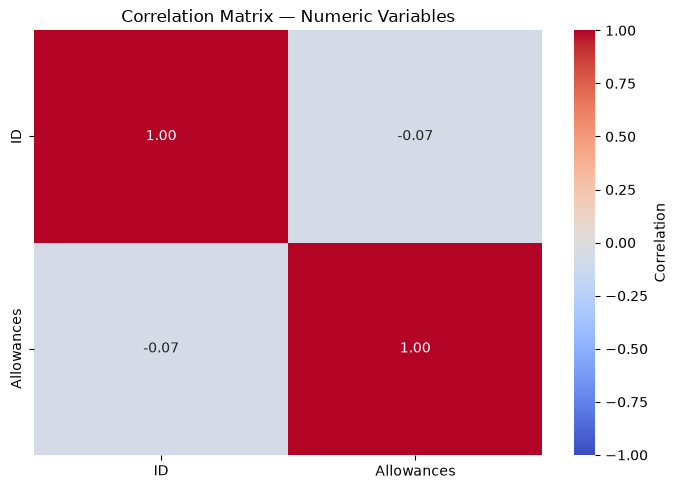

,ID,Allowances
ID,1.00,-0.07
Allowances,-0.07,1.00


In [12]:
# CORRELATION ANALYSIS

# Select numeric columns
numeric_for_corr = eda_df.select_dtypes(include=np.number)

if not numeric_for_corr.empty:
    corr = numeric_for_corr.corr(numeric_only=True)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        corr, 
        annot=True,        # show correlation values
        fmt=".2f",         # format to 2 decimal places
        cmap="coolwarm",   # color scheme
        vmin=-1, vmax=1,   # correlation range
        cbar_kws={"label": "Correlation"}
    )

    plt.title("Correlation Matrix — Numeric Variables")
    plt.tight_layout()
    plt.show()

    display(corr.round(2))


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Stage 05</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Data Cleaning</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Prepare a reliable analytical dataset by resolving quality issues before modeling.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roman">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roman">

# 5️⃣ Data Cleaning

The guideline requires handling missing values, duplicates, incorrect data types, and outliers when required.

For this dataset:

- Text fields contain inconsistent leading/trailing spaces and non-breaking spaces → normalize them.
- `ID` is an identifier, not a predictive employee characteristic → exclude it from model features.
- No duplicate rows were found during inspection.
- Missing values are handled safely inside the preprocessing pipeline.
- Outlier treatment is not applied blindly because the dataset does not contain a conventional continuous numeric feature set requiring statistical outlier removal.
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 13</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Data Cleaning</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Apply the defined cleaning rules to produce a consistent modeling dataset.</p></div>


In [13]:
# DATA CLEANING

clean_df = df.copy()

# Standardize column names.
clean_df.columns = [
    str(c).replace("\xa0", " ").strip()
    for c in clean_df.columns
]

# Standardize text values.
for col in clean_df.select_dtypes(include="object").columns:
    clean_df[col] = (
        clean_df[col].astype(str)
        .str.replace("\xa0", " ", regex=False)
        .str.strip()
    )

# Remove exact duplicate rows.
before = len(clean_df)
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", len(clean_df))
print("Duplicates removed:", before - len(clean_df))

print("\nRemaining missing values:", int(clean_df.isna().sum().sum()))


Rows before duplicate removal: 1191
Rows after duplicate removal: 1191
Duplicates removed: 0

Remaining missing values: 0


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Stage 06</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Data Preprocessing</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Transform raw variables into model-ready features while preserving the information required for prediction.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roman">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roman">

# 6️⃣ Data Preprocessing

The guideline asks for encoding, scaling when required, and feature selection when required.

### Strategy

- **One-Hot Encoding:** required because most predictors are categorical.
- **Scaling:** used for Logistic Regression; it is not required by tree-based models, but using a common preprocessing pipeline keeps the comparison consistent.
- **Feature Selection:** `ID` is removed because it is an identifier rather than a meaningful predictive feature.
- **Missing values:** handled with imputers inside the pipeline to avoid data leakage.
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 14</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Feature & Target Definition</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Separate predictors from the attrition target and establish the feature matrix used by downstream models.</p></div>


In [14]:
# DEFINE FEATURES AND TARGET

X = clean_df.drop(columns=[TARGET, "ID"])
y = clean_df[TARGET].map({"No": 0, "Yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", X.columns.tolist())


X shape: (1191, 33)
y shape: (1191,)
Features: ['Gender', 'Age', 'Maritalstatus', 'Academic_degree', 'Years_Experience', 'Years_experience_lastorganization', 'Sector', 'Department', 'JobTitle', 'MonthlySalary', 'Allowances', 'MedicalInsurance', 'Bonus', 'OverTime', 'Payment_Overtime', 'Rewards&Wages_Satisfaction', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Useful_Training_Programs', 'Business_Travel', 'Job_Support', 'Recognition', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Health_Issues', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities']


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 15</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Train–Test Split</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Create a reproducible holdout split for unbiased model evaluation.</p></div>


In [26]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(2))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(2))


Training set: (952, 33)
Testing set : (239, 33)

Training target distribution:
Attrition
0    0.57
1    0.43
Name: proportion, dtype: float64

Testing target distribution:
Attrition
0    0.57
1    0.43
Name: proportion, dtype: float64


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 16</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Preprocessing Pipeline</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Build the preprocessing pipeline for numerical and categorical features.</p></div>


In [16]:
# BUILD PREPROCESSOR

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical feature count:", len(categorical_features))


Numeric features: ['Allowances']
Categorical feature count: 32


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Stage 07</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Model Building</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Train multiple classifiers to establish meaningful baselines and compare model behavior.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roman">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roman">

# 7️⃣ Model Building

We compare multiple classification algorithms rather than assuming one model is automatically best.

### Baseline / comparison models

1. Logistic Regression — interpretable linear baseline
2. Decision Tree — nonlinear rule-based model
3. Random Forest — ensemble of decision trees
4. XGBoost — gradient-boosted tree ensemble

The guideline requires selecting an appropriate model and training it. 
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 17</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Baseline Model Configuration</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Configure multiple baseline classification algorithms for a fair comparison.</p></div>


In [17]:
# BUILD BASELINE MODELS

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=6
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("Models prepared:", list(pipelines.keys()))


Models prepared: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 18</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Baseline Model Training</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Train the baseline classifiers using the same preprocessing framework.</p></div>


In [18]:
# TRAIN BASELINE MODELS

results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred)*100,2),
        "Precision":round( precision_score(y_test, pred, zero_division=0)*100,2),
        "Recall": round(recall_score(y_test, pred, zero_division=0)*100,2),
        "F1": round(f1_score(y_test, pred, zero_division=0)*100,2),
        "ROC-AUC": round(roc_auc_score(y_test, prob)*100,2)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,82.01,81.25,75.73,78.39,90.16
1,Logistic Regression,79.08,77.32,72.82,75.00,88.61
2,Random Forest,77.82,73.58,75.73,74.64,86.21
3,Decision Tree,75.31,73.91,66.02,69.74,77.76


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Stage 08</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Model Evaluation</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Measure model performance using classification metrics that matter for attrition risk detection.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roman">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roman">

# 8️⃣ Model Evaluation

For classification, the supplied guideline requires:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

These metrics are therefore reported for the candidate models. 

For attrition, **Recall and F1 should be considered carefully** because missing a genuinely at-risk employee can be more costly than investigating an additional false positive.
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 19</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Detailed Model Evaluation</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Generate detailed predictions and classification metrics for model comparison.</p></div>


Best baseline model: XGBoost

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.83      0.87      0.85       136
   Attrition       0.81      0.76      0.78       103

    accuracy                           0.82       239
   macro avg       0.82      0.81      0.81       239
weighted avg       0.82      0.82      0.82       239

ROC-AUC: 0.9016


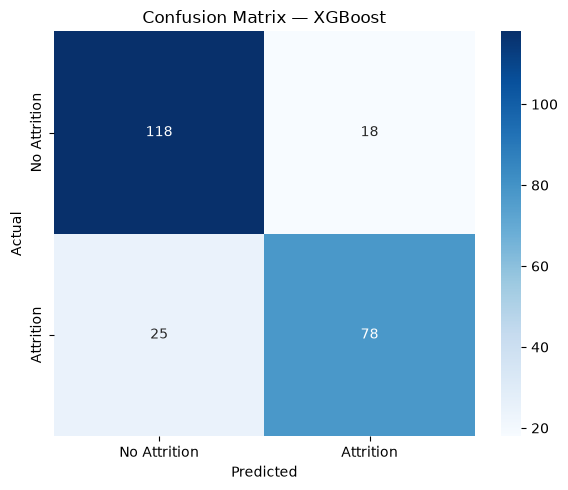

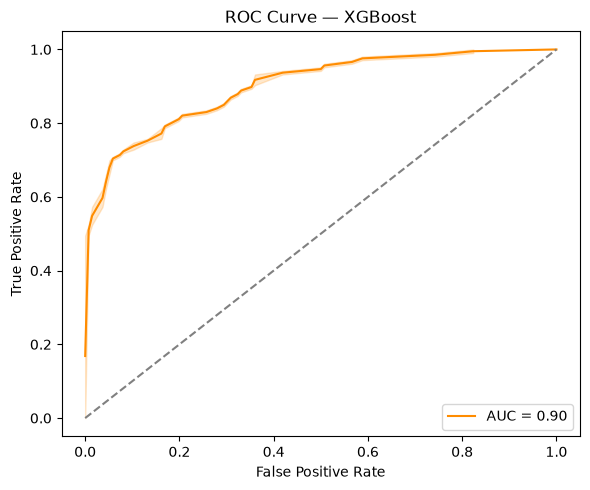

In [36]:
# DETAILED EVALUATION OF THE CURRENT BEST BASELINE

best_baseline_name = results_df.iloc[0]["Model"]
best_baseline = pipelines[best_baseline_name]

best_pred = best_baseline.predict(X_test)
best_prob = best_baseline.predict_proba(X_test)[:, 1]

print("Best baseline model:", best_baseline_name)
print("\nClassification Report:")
print(classification_report(
    y_test,
    best_pred,
    target_names=["No Attrition", "Attrition"]
))

print("ROC-AUC:", round(roc_auc_score(y_test, best_prob), 4))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)  # best_pred = model predictions
plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="Blues", 
            cbar=True, 
            xticklabels=["No Attrition", "Attrition"], 
            yticklabels=["No Attrition", "Attrition"]
            )
plt.title(f"Confusion Matrix — {best_baseline_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_prob)  # best_prob = predicted probabilities
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--", color="gray")  # diagonal line
plt.title(f"ROC Curve — {best_baseline_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Stage 09</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Hyperparameter Tuning</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Optimize the strongest candidate using systematic hyperparameter search.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roman">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roman">

# 9️⃣ Hyperparameter Tuning

The guideline requires **GridSearchCV or RandomizedSearchCV**

Here we tune XGBoost using `GridSearchCV`. The search is performed on the complete pipeline so preprocessing is learned only from the training folds.
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 20</div><h2 style="margin:0;color:#1f2937;font-size:25px;">XGBoost Hyperparameter Tuning</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Search the XGBoost hyperparameter space to improve the strongest tree-based candidate.</p></div>


In [20]:
# XGBOOST HYPERPARAMETER TUNING

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param = {
    # Number of boosting trees
    "model__n_estimators": [200, 300, 400],
    # Step size for each boosting iteration
    "model__learning_rate": [0.05, 0.1],
    # Maximum depth of each tree
    "model__max_depth": [3, 5, 7],
    # Minimum sum of instance weight required in a child
    "model__min_child_weight": [1, 2, 4],
    # Fraction of training samples used for each tree
    "model__subsample": [0.8, 1.0],
    # Fraction of features used for each tree
    "model__colsample_bytree": [0.8, 1.0],
    # Minimum loss reduction required for a split
    "model__gamma": [0, 0.2]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)
print("\nBest CV F1:", round(search.best_score_, 4))


Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best parameters:
{'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 2, 'model__n_estimators': 400, 'model__subsample': 0.8}

Best CV F1: 0.7876


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 21</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Tuned XGBoost Evaluation</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Evaluate the tuned XGBoost model on the held-out test set.</p></div>


,Accuracy,Precision,Recall,F1,ROC-AUC
Tuned XGBoost,82.01,81.25,75.73,78.39,90.16



Classification Report:
              precision    recall  f1-score   support

No Attrition       0.83      0.88      0.86       136
   Attrition       0.83      0.77      0.80       103

    accuracy                           0.83       239
   macro avg       0.83      0.82      0.83       239
weighted avg       0.83      0.83      0.83       239



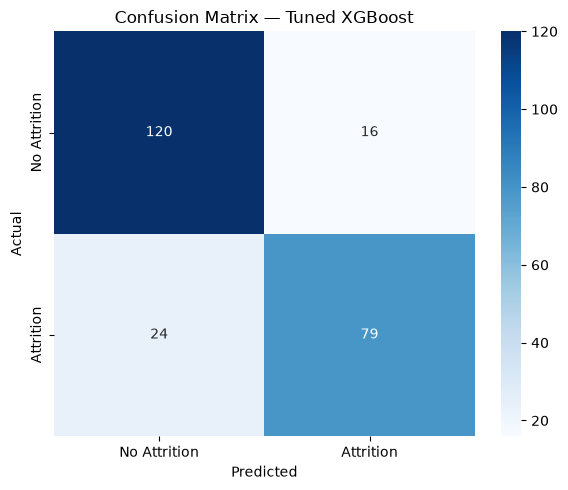

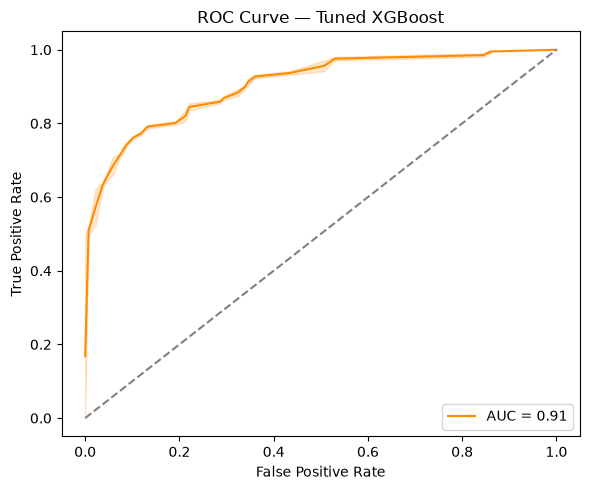

In [32]:
# --- Metrics ---
tuned_model = search.best_estimator_
tuned_pred = tuned_model.predict(X_test)
tuned_prob = tuned_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": round(accuracy_score(y_test, pred)*100,2),
    "Precision":round( precision_score(y_test, pred, zero_division=0)*100,2),
    "Recall": round(recall_score(y_test, pred, zero_division=0)*100,2),
    "F1": round(f1_score(y_test, pred, zero_division=0)*100,2),
    "ROC-AUC": round(roc_auc_score(y_test, prob)*100,2)
}

display(pd.DataFrame([tuned_metrics], index=["Tuned XGBoost"]).round(2))

print("\nClassification Report:")
print(classification_report(
    y_test,
    tuned_pred,
    target_names=["No Attrition", "Attrition"]
))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, tuned_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)
plt.title("Confusion Matrix — Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, tuned_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--", color="gray")  # baseline
plt.title("ROC Curve — Tuned XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#6C5CE7;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Stage 10</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Final Model Selection</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Select the final model using a balanced view of predictive performance and business usefulness.</p></div><details style="background:#fff;border:1px solid #e5e7eb;border-radius:14px;padding:12px 18px;margin-bottom:18px;">
<summary style="cursor:pointer;font-weight:700;color:#374151;font-family: Times New Roman">View detailed guidance</summary>
<div style="padding-top:12px;color:#4b5563;line-height:1.7;font-family: Times New Roman">

# 🔟 Final Model Selection

Do not select the final model only because it has the highest accuracy.

For this business problem, compare **F1, Recall, Precision, and ROC-AUC** together. If HR's priority is catching as many potential attrition cases as possible, Recall may receive greater weight; if intervention capacity is limited, Precision becomes more important.

Use the test-set results and the project objective to justify the final model in the viva.
</div>
</details>


<div style="background:linear-gradient(135deg,#ffffff 0%,#f7f5ff 100%);border:1px solid #e7e3f8;border-radius:18px;padding:22px 26px;margin:10px 0 22px;box-shadow:0 8px 24px rgba(31,41,55,.06);font-family: Times New Roman">
<div style="font-size:13px;font-weight:700;color:#0EA5A4;letter-spacing:1.2px;text-transform:uppercase;margin-bottom:8px;">Execution 22</div><h2 style="margin:0;color:#1f2937;font-size:25px;">Final Model Comparison</h2><p style="margin:8px 0 0;color:#667085;font-size:15px;line-height:1.6;">Compare candidate models and identify the final model using the project's evaluation criteria.</p></div>


In [22]:
# FINAL MODEL COMPARISON

final_results = results_df.copy()

final_results = pd.concat([
    final_results,
    pd.DataFrame([{
        "Model": "Tuned XGBoost",
    **tuned_metrics
    }])
], ignore_index=True)

display(final_results.sort_values(
    ["F1", "ROC-AUC"],
    ascending=False
).round(2))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,82.01,81.25,75.73,78.39,90.16
1,Logistic Regression,79.08,77.32,72.82,75.00,88.61
2,Random Forest,77.82,73.58,75.73,74.64,86.21
3,Decision Tree,75.31,73.91,66.02,69.74,77.76
4,Tuned XGBoost,0.83,0.83,0.77,0.80,0.91
